In [1]:
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [6]:
PROJECT_ROOT = Path("../")

DATA_DIR = PROJECT_ROOT / "data"

RAW_DATA_DIR = DATA_DIR / "raw"

DATASET_DIR = RAW_DATA_DIR / "cifar10"

TRAIN_DIR = DATASET_DIR / "cifar10/train"

TEST_DIR = DATASET_DIR / "cifar10/test"

In [7]:
print("=" * 50)

print("Dataset Exists :", DATASET_DIR.exists())

print("Train Exists   :", TRAIN_DIR.exists())

print("Test Exists    :", TEST_DIR.exists())

print("=" * 50)

Dataset Exists : True
Train Exists   : True
Test Exists    : True


In [8]:
print("Dataset Structure\n")

for item in DATASET_DIR.iterdir():
    print(item.name)

Dataset Structure

cifar10


In [9]:
classes = sorted([
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
])

print("Number of Classes :", len(classes))

print()

print(classes)

Number of Classes : 10

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [10]:
class_mapping = {
    idx: name
    for idx, name in enumerate(classes)
}

pd.DataFrame(
    class_mapping.items(),
    columns=["Label", "Class"]
)

,Label,Class
0,0,airplane
1,1,automobile
2,2,bird
3,3,cat
4,4,deer
5,5,dog
6,6,frog
7,7,horse
8,8,ship
9,9,truck


In [11]:
image_counts = {}

for class_name in classes:

    class_path = TRAIN_DIR / class_name

    images = list(class_path.glob("*"))

    image_counts[class_name] = len(images)

image_counts

{'airplane': 5000,
 'automobile': 5000,
 'bird': 5000,
 'cat': 5000,
 'deer': 5000,
 'dog': 5000,
 'frog': 5000,
 'horse': 5000,
 'ship': 5000,
 'truck': 5000}

In [12]:
class_df = pd.DataFrame(

    image_counts.items(),

    columns=["Class", "Images"]

)
class_df

,Class,Images
0,airplane,5000
1,automobile,5000
2,bird,5000
3,cat,5000
4,deer,5000
5,dog,5000
6,frog,5000
7,horse,5000
8,ship,5000
9,truck,5000


In [13]:
print("=" * 40)

print("Total Classes :", len(classes))

print("Total Training Images :", class_df["Images"].sum())

print("Average Images per Class :", class_df["Images"].mean())

print("Minimum Images :", class_df["Images"].min())

print("Maximum Images :", class_df["Images"].max())

print("=" * 40)

Total Classes : 10
Total Training Images : 50000
Average Images per Class : 5000.0
Minimum Images : 5000
Maximum Images : 5000


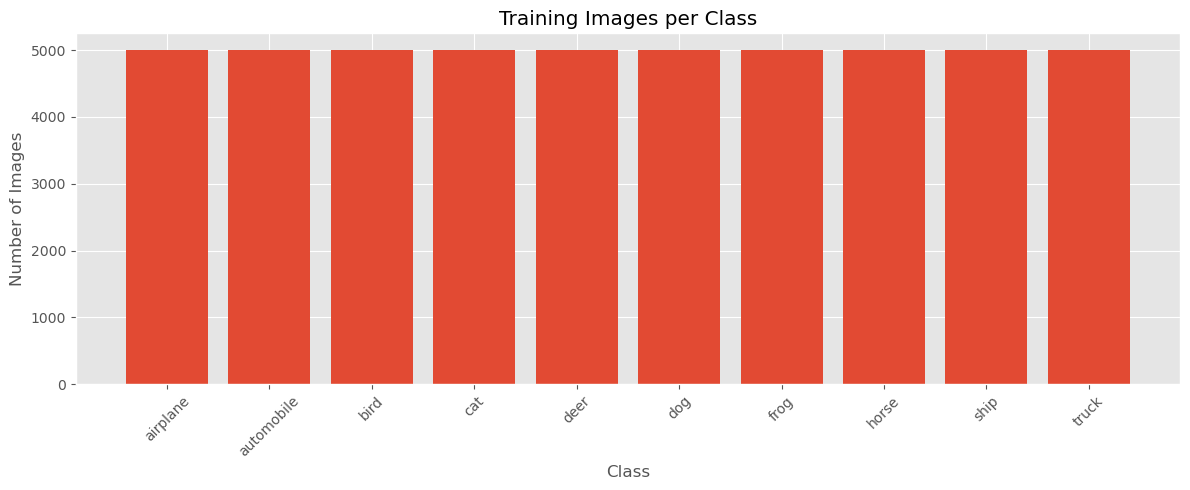

In [14]:
plt.figure(figsize=(12,5))

plt.bar(class_df["Class"], class_df["Images"])

plt.xticks(rotation=45)

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.title("Training Images per Class")

plt.tight_layout()

plt.show()

In [15]:
test_counts = {}

for class_name in classes:

    class_path = TEST_DIR / class_name

    images = list(class_path.glob("*"))

    test_counts[class_name] = len(images)

test_df = pd.DataFrame(

    test_counts.items(),

    columns=["Class","Test Images"]

)

test_df

,Class,Test Images
0,airplane,1000
1,automobile,1000
2,bird,1000
3,cat,1000
4,deer,1000
5,dog,1000
6,frog,1000
7,horse,1000
8,ship,1000
9,truck,1000


In [16]:
comparison = class_df.copy()

comparison["Test Images"] = test_df["Test Images"]

comparison

,Class,Images,Test Images
0,airplane,5000,1000
1,automobile,5000,1000
2,bird,5000,1000
3,cat,5000,1000
4,deer,5000,1000
5,dog,5000,1000
6,frog,5000,1000
7,horse,5000,1000
8,ship,5000,1000
9,truck,5000,1000


In [17]:
balanced = comparison["Images"].nunique() == 1

print("Training Dataset Balanced :", balanced)

balanced_test = comparison["Test Images"].nunique() == 1

print("Testing Dataset Balanced :", balanced_test)

Training Dataset Balanced : True
Testing Dataset Balanced : True


In [18]:
summary = {

    "Classes": len(classes),

    "Training Images": comparison["Images"].sum(),

    "Testing Images": comparison["Test Images"].sum(),

    "Balanced Train": balanced,

    "Balanced Test": balanced_test

}

summary

{'Classes': 10,
 'Training Images': np.int64(50000),
 'Testing Images': np.int64(10000),
 'Balanced Train': True,
 'Balanced Test': True}